In [ ]:
!pip install navis --quiet

In [ ]:
import navis
navis.set_loggers('ERROR')
import navis.interfaces.neuromorpho as nm
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import requests

hippo_info = nm.find_neurons(species="rat", brain_region="hippocampus", cell_type="pyramidal")
neocortex_info = nm.find_neurons(species="rat", brain_region="neocortex", cell_type="pyramidal")

hippo_sample = hippo_info.head(20)
neocortex_sample = neocortex_info.head(20)

hippo_neuron_names = hippo_sample["neuron_name"].tolist()
neocortex_neuron_names = neocortex_sample["neuron_name"].tolist()

hippo_metrics = []
for name in hippo_neuron_names:
    neuron = navis.interfaces.neuromorpho.get_neuron(name)
    hippo_metrics.append({
        "neuron_name": name,
        "n_branches": neuron.n_branches,
        "n_leafs": neuron.n_leafs,
        "cable_length": neuron.cable_length
    })

neocortex_metrics = []
for name in neocortex_neuron_names:
    neuron = navis.interfaces.neuromorpho.get_neuron(name)
    neocortex_metrics.append({
        "neuron_name": name,
        "n_branches": neuron.n_branches,
        "n_leafs": neuron.n_leafs,
        "cable_length": neuron.cable_length
    })

hippo_df = pd.DataFrame(hippo_metrics)
neocortex_df = pd.DataFrame(neocortex_metrics)

hippo_df["branches_per_length"] = hippo_df["n_branches"] / hippo_df["cable_length"]
neocortex_df["branches_per_length"] = neocortex_df["n_branches"] / neocortex_df["cable_length"]

print("Setup complete.")
print(hippo_df.shape, neocortex_df.shape)

Setup complete.
(20, 5) (20, 5)


In [ ]:
print("Hippocampus - avg branches:", hippo_df["n_branches"].mean())
print("Neocortex - avg branches:", neocortex_df["n_branches"].mean())
print("Hippocampus - avg leafs:", hippo_df["n_leafs"].mean())
print("Neocortex - avg leafs:", neocortex_df["n_leafs"].mean())
print("Hippocampus - avg cable length:", hippo_df["cable_length"].mean())
print("Neocortex - avg cable length:", neocortex_df["cable_length"].mean())
print("Hippocampus - branches per length:", hippo_df["branches_per_length"].mean())
print("Neocortex - branches per length:", neocortex_df["branches_per_length"].mean())

Hippocampus - avg branches: 98.0
Neocortex - avg branches: 103.5
Hippocampus - avg leafs: 101.2
Neocortex - avg leafs: 112.7
Hippocampus - avg cable length: 4495.6865
Neocortex - avg cable length: 15209.362
Hippocampus - branches per length: 0.028607784387626577
Neocortex - branches per length: 0.013546545842192009


In [ ]:
print(hippo_df[hippo_df["cable_length"] > 10000])

  neuron_name  n_branches  n_leafs  cable_length  branches_per_length
0        n419          78       81  13172.156250             0.005922
1        n420          69       72  12841.359375             0.005373
9        n421          78       81  14269.828125             0.005466


In [ ]:
t_stat, p_value = stats.ttest_ind(hippo_df["cable_length"], neocortex_df["cable_length"], equal_var=False)
print("cable_length t-statistic:", t_stat)
print("cable_length p-value:", p_value)

t_stat_branches, p_value_branches = stats.ttest_ind(hippo_df["n_branches"], neocortex_df["n_branches"], equal_var=False)
print("n_branches t-statistic:", t_stat_branches)
print("n_branches p-value:", p_value_branches)

t_stat_bpl, p_value_bpl = stats.ttest_ind(hippo_df["branches_per_length"], neocortex_df["branches_per_length"], equal_var=False)
print("branches_per_length t-statistic:", t_stat_bpl)
print("branches_per_length p-value:", p_value_bpl)

cable_length t-statistic: -5.739047992336554
cable_length p-value: 3.120771564507403e-06
n_branches t-statistic: -0.2218987001413944
n_branches p-value: 0.8258506548040394
branches_per_length t-statistic: 1.822301876438186
branches_per_length p-value: 0.08051621767802675


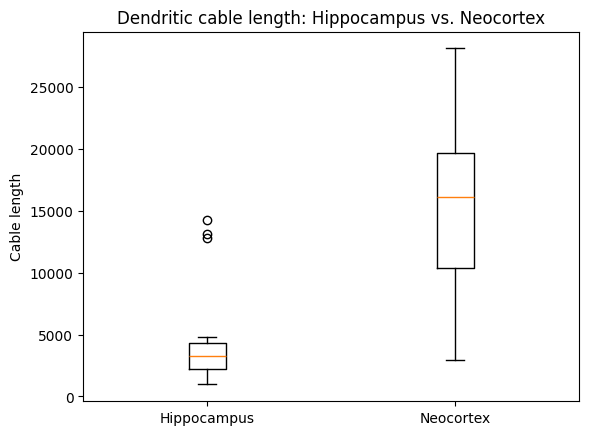

In [ ]:
plt.boxplot([hippo_df["cable_length"], neocortex_df["cable_length"]], tick_labels=["Hippocampus", "Neocortex"])
plt.ylabel("Cable length")
plt.title("Dendritic cable length: Hippocampus vs. Neocortex")
plt.savefig("boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

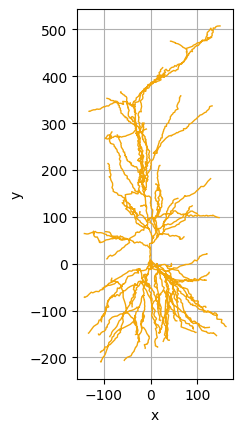

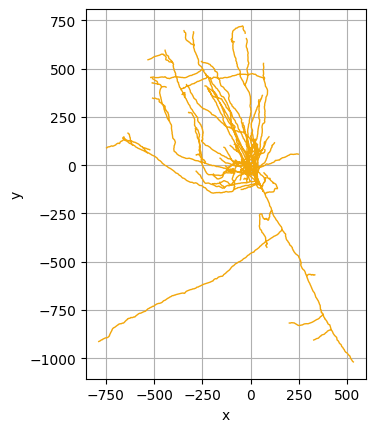

In [ ]:
hippo_example = navis.interfaces.neuromorpho.get_neuron(hippo_neuron_names[0])
neocortex_example = navis.interfaces.neuromorpho.get_neuron(neocortex_neuron_names[0])

fig, ax = navis.plot2d(hippo_example)
fig.savefig("hippo_morphology.png", dpi=300, bbox_inches="tight")

fig2, ax2 = navis.plot2d(neocortex_example)
fig2.savefig("neocortex_morphology.png", dpi=300, bbox_inches="tight")

In [ ]:
all_dois = list(hippo_sample["reference_doi"]) + list(neocortex_sample["reference_doi"])
unique_dois = set()
for doi_list in all_dois:
    for doi in doi_list:
        unique_dois.add(doi)

for doi in unique_dois:
    response = requests.get(f"https://api.crossref.org/works/{doi}")
    data = response.json()
    title = data["message"]["title"][0]
    journal = data["message"]["container-title"][0]
    year = data["message"]["published"]["date-parts"][0][0]
    authors = data["message"]["author"]
    author_names = []
    for a in authors:
        author_names.append(a["family"] + " " + a["given"][0] + ".")
    author_string = ", ".join(author_names)
    print(f"{author_string} ({year}). {title}. {journal}. https://doi.org/{doi}")
    print("---")

Krichmar J., Velasquez D., Ascoli G. (2006). Effects of β-Catenin on Dendritic Morphology and Simulated Firing Patterns in Cultured Hippocampal Neurons. The Biological Bulletin. https://doi.org/10.2307/4134575
---
Staiger J. (2004). Functional Diversity of Layer IV Spiny Neurons in Rat Somatosensory Cortex: Quantitative Morphology of Electrophysiologically Characterized and Biocytin Labeled Cells. Cerebral Cortex. https://doi.org/10.1093/cercor/bhh029
---
Yu X., Malenka R. (2003). β-catenin is critical for dendritic morphogenesis. Nature Neuroscience. https://doi.org/10.1038/nn1132
---
Averkin R., Szemenyei V., Bordé S., Tamás G. (2016). Identified Cellular Correlates of Neocortical Ripple and High-Gamma Oscillations during Spindles of Natural Sleep. Neuron. https://doi.org/10.1016/j.neuron.2016.09.032
---
Ueta Y., Otsuka T., Morishima M., Ushimaru M., Kawaguchi Y. (2013). Multiple Layer 5 Pyramidal Cell Subtypes Relay Cortical Feedback from Secondary to Primary Motor Areas in Rats. Ce